In [ ]:
pip install EMD-signal

In [2]:
import PyEMD
print(PyEMD.__version__)

1.6.4


In [ ]:
import matplotlib.pyplot as plt
# 导入matplotlib的pyplot模块，用于数据可视化。
import tensorflow as tf
# 导入tensorflow库，用于深度学习模型的构建和训练
from PyEMD import EMD, EEMD, CEEMDAN
# 从pyemd库导入EMD, EEMD, CEEMDAN，用于模态分解
import pandas as pd
# 导入pandas库，用于数据处理和分析
import warnings
# 导入warnings库，用于控制警告消息
warnings.filterwarnings("ignore")

In [4]:
gpus = tf.config.experimental.list_physical_devices(device_type='GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [5]:
# 用来正常显示中文/英文标签（保持与模板一致）
plt.rcParams['font.sans-serif'] = ['Times New Roman']
# 用来正常显示负号
plt.rcParams['axes.unicode_minus'] = False

In [6]:
df_raw_data = pd.read_csv('INDIA-FloodPrediction.csv')

# 确保时间列为Datetime并按时间排序
df_raw_data['Month'] = pd.to_datetime(df_raw_data['Month'])
df_raw_data = df_raw_data.sort_values('Month').reset_index(drop=True)

# 只分解目标 rx5day（推荐做法）
series_close = pd.Series(
    df_raw_data['rx5day'].astype(float).values,
    index=df_raw_data['Month']
)
# 创建一个pandas的Series对象。
# df_raw_data['rx5day'].values提取'rx5day'列的值作为Series的数据。
# index=df_raw_data['Month']设置Series的索引为时间戳（YYYY-MM）
print(series_close)

Month
1950-01-01    16.52
1950-02-01    23.39
1950-03-01    38.71
1950-04-01    16.98
1950-05-01    42.97
              ...  
2023-08-01    79.29
2023-09-01    96.53
2023-10-01    40.35
2023-11-01    30.13
2023-12-01    26.50
Length: 888, dtype: float64


In [7]:
def ceemdan_decompose(series=None, trials=100):
    # 定义CEEMDAN分解函数。
    # series: 待分解的时间序列数据。
    # trials: CEEMDAN的试验次数，用于生成噪声。

    decom = CEEMDAN()
    # 创建CEEMDAN对象。

    decom.trials = trials
    # 设置CEEMDAN对象的试验次数。

    df_ceemdan = pd.DataFrame(decom(series.values).T)
    # 对时间序列数据执行CEEMDAN分解，并将结果转置后转换为DataFrame。

    df_ceemdan.columns = ['imf' + str(i+1) for i in range(len(df_ceemdan.columns))]
    # 为DataFrame的每一列命名，表示每个内在模态函数（IMF）。

    return df_ceemdan
    # 返回分解结果的DataFrame。

In [8]:
df_ceemdan = ceemdan_decompose(series_close)
# 对series_close进行CEEMDAN分解，并返回结果的DataFrame。

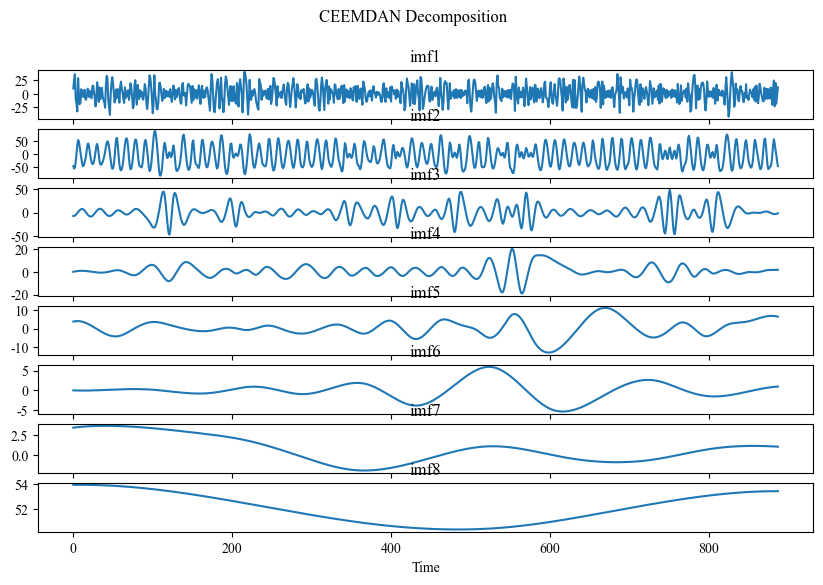

In [9]:
# 可视化VMD分解结果
fig, axs = plt.subplots(nrows=len(df_ceemdan.columns), figsize=(10, 6), sharex=True)
# 创建一个绘图对象和多个子图对象。
for i, col in enumerate(df_ceemdan.columns):
    axs[i].plot(df_ceemdan[col])
    axs[i].set_title(col)
    # 遍历每个模态并绘制在子图上。

plt.suptitle('CEEMDAN Decomposition')
# 设置图表的总标题。

plt.xlabel('Time')
# 设置x轴的标签。

plt.show()
# 显示图表。

In [10]:
print(df_ceemdan)
df_ceemdan.to_excel("CEEMDAN-INDIA-RX5DAY.xlsx",index=False)
#保存数据为CEEMDAN-CHINA-RX5DAY.xlsx

          imf1       imf2      imf3      imf4      imf5      imf6      imf7  \
0    10.054412 -47.607128 -7.140177 -0.020461  3.839366 -0.031375  3.489795   
1    26.384394 -57.292754 -7.147757  0.129206  3.918133 -0.038992  3.501631   
2    36.042489 -52.647079 -6.335434  0.264271  3.981932 -0.045958  3.513148   
3    -8.904749 -31.079634 -4.859503  0.384633  4.030129 -0.052268  3.524345   
4   -17.448798   1.382032 -2.930510  0.490493  4.062091 -0.057914  3.535223   
..         ...        ...       ...       ...       ...       ...       ...   
883 -22.834066  41.618347 -3.243815  1.597800  6.769910  0.877809  1.073338   
884  20.008911  15.875595 -3.077514  1.617545  6.711315  0.895444  1.067735   
885 -18.196232  -2.442565 -2.702371  1.646929  6.639427  0.911705  1.061943   
886  -3.398215 -27.968473 -2.156412  1.684955  6.554300  0.926616  1.055963   
887  11.875625 -47.505848 -1.477661  1.730625  6.455991  0.940200  1.049798   

          imf8  
0    53.935568  
1    53.936139  
